In [1]:
import numpy as np
import matplotlib.pyplot as plt

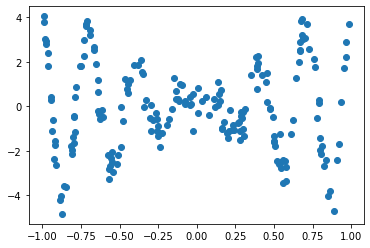

In [2]:
# let us generate some (toy) data based on y = 5x sin(20x)

m = 200 # number of points

x = -1 + 2*np.random.rand(m) # m random points on [-1,1]
y = 5*x*np.sin(20*x) + 0.5*np.random.randn(m)
plt.scatter(x,y)

In [3]:
def build_poly_features(X,degree=1):
    from itertools import combinations_with_replacement as combwr
    from itertools import chain
    
    # number of data points (rows), number of features (columns)
    
    try:
        m,n = X.shape # will not work when x is a vector
    except:
        m = len(X)
        n = 1
        X = X.reshape(m,1)
    
    # number of polynomial features
    
    combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
    n_poly = sum(1 for combination in combinations)
    
    # polynomial feature matrix
    combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
    X_poly = np.ones((m,n_poly))
    for column_index, combination in enumerate(combinations):
        X_poly[:,column_index] = np.product(X[:,combination],axis = 1)
        
    return X_poly

In [4]:
# training - test split
x_train,y_train = x[0:m*3//4], y[0:m*3//4]
x_test, y_test = x[m*3//4:m], y[m*3//4:m]

training set mean squared error:  0.16689685340445848
testing set mean squared error:  20993036283137.832


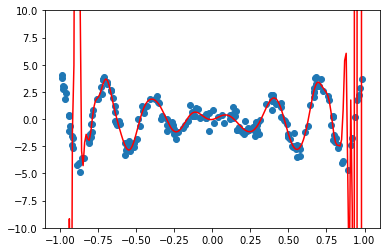

In [5]:
# fit a degree d polynomial
d = 2000
X_poly_train = build_poly_features(x_train,degree=d)
X_poly_test = build_poly_features(x_test,degree=d)
# solve lstsq
theta = np.linalg.lstsq(X_poly_train,y_train,rcond=None)[0]
m_plot = 200
x_plot = np.linspace(-1,1,m_plot)

x_plot_poly = build_poly_features(x_plot,degree=d)
y_plot = x_plot_poly.dot(theta)

plt.ylim([-10,10])

plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

# mean squared errors

mse_train = np.mean((y_train-X_poly_train.dot(theta))**2)
mse_test = np.mean((y_test-X_poly_test.dot(theta))**2)
print('training set mean squared error: ' , mse_train)
print('testing set mean squared error: ' , mse_test)

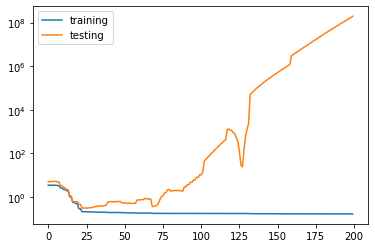

In [6]:
d_max = 200

mse_train = np.zeros(d_max)
mse_test = np.zeros(d_max)

for d in range(d_max):
    X_poly_train = build_poly_features(x_train,degree=d)
    X_poly_test = build_poly_features(x_test,degree=d)
    theta = np.linalg.lstsq(X_poly_train,y_train,rcond=None)[0]
    
    mse_train[d] = np.mean((y_train-X_poly_train.dot(theta))**2)
    mse_test[d] = np.mean((y_test-X_poly_test.dot(theta))**2)
    
plt.semilogy(mse_train, label = 'training')
plt.semilogy(mse_test, label = 'testing')
plt.legend()

****
## Some Notes on Overfitting and Regularization to Start the day 1/28

*Overfitting*: the model fits the data 'well,' but generalizes poorly to any new data.

Why? Likely, your model is too complex.

Example: Fitting a polynomial of very high degree (relative to the size of the data set) to our data.

**Detecting Overfitting:**

Partition your dataset into parts A, B, say with A containing 75% of the data an B containing 25% of the data.

We'll use A as our 'training set' to fit our model and use B and our 'testing set' to assess the quality of the fitted model.

Then, we can plot the mean squared error for the testing set and training set against the degree of our model, which will show for which degrees we underfit and overfit our data.

*Back to Programming*
****
*Back to Notes*

Typically, overfitting arises from having at least one very large coefficient. So maybe we try to keep the coefficients small when fitting our data.

*Regularization:* $$\min \|y-X\theta\|^2/m+c \|\theta\|^2/m$$ where $c$ is called our 'regularization constant.'

Note that setting $c=0$ gives us a normal linear regression problem.

If $c$ is too large, the solution will just be $\theta = 0$.

### Linear Regression and Regularization

In a normal linear regression problem, we know how to find $\theta$ as it satisfies the system $X^TX\theta = X^TY$ (The normal equations).

With Regularization, $\theta$ satisfies $(X^TX+cI)\theta = X^Ty$
****

training set mean squared error:  3.4823117385185833
testing set mean squared error:  5.072164699424654


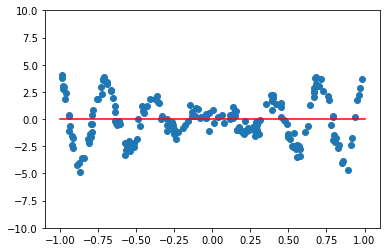

In [7]:
# Regularization

# fit a degree d polynomial
d = 100
C = 1e16
X_poly_train = build_poly_features(x_train,degree=d)
X_poly_test = build_poly_features(x_test,degree=d)
# solve lstsq
theta = np.linalg.solve(X_poly_train.T.dot(X_poly_train)+C*np.eye(d+1), X_poly_train.T.dot(y_train))
m_plot = 200
x_plot = np.linspace(-1,1,m_plot)

x_plot_poly = build_poly_features(x_plot,degree=d)
y_plot = x_plot_poly.dot(theta)

plt.ylim([-10,10])

plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

# mean squared errors

mse_train = np.mean((y_train-X_poly_train.dot(theta))**2)
mse_test = np.mean((y_test-X_poly_test.dot(theta))**2)
print('training set mean squared error: ' , mse_train)
print('testing set mean squared error: ' , mse_test)

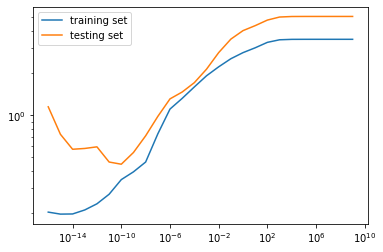

In [8]:
# Let us plot the mse's as a function of C.
C_list = 10.0**(np.arange(-16, 10))

mse_train = np.zeros(len(C_list)) 
mse_test = mse_test = np.zeros(len(C_list))

for i,C in enumerate(C_list):
    X_poly_train = build_poly_features(x_train,degree=d)
    X_poly_test = build_poly_features(x_test,degree=d)
    # solve lstsq
    theta = np.linalg.solve(X_poly_train.T.dot(X_poly_train)+C*np.eye(d+1), X_poly_train.T.dot(y_train))
    
    mse_train[i] = np.mean((y_train - X_poly_train.dot(theta))**2)
    mse_test[i] = np.mean((y_test-X_poly_test.dot(theta))**2)
    
plt.loglog(C_list, mse_train, label = 'training set')
plt.loglog(C_list, mse_test, label = 'testing set')
plt.legend()

maybe we pick C = 10^(-10), I guess.